In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [37]:
torch.cuda.is_available()
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [38]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # Normalize before flattening
    transforms.Lambda(lambda x: x.view(-1))  # Flatten the image (28*28 = 784)
])
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, transform=transform, download=True
)


In [39]:
image, label = train_dataset[0]
print(f"Flattened image shape: {image.shape}")  # Should print: torch.Size([784])
print(f"Label: {label}")

Flattened image shape: torch.Size([784])
Label: 9


In [40]:
print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Training dataset size: 60000
Test dataset size: 10000


<h1><center>Model (1)<center><h1>


In [41]:

class FashionMNIST_ANN(nn.Module):
    def __init__(self):
        super(FashionMNIST_ANN, self).__init__()
        self.fc1 = nn.Linear(784, 128)  # First hidden layer
        self.fc2 = nn.Linear(128, 64)   # Second hidden layer
        self.fc3 = nn.Linear(64, 10)    # Output layer (10 classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))  # Activation function for first hidden layer
        x = F.relu(self.fc2(x))  # Activation function for second hidden layer
        x = self.fc3(x)          # No activation (logits for classification)
        return x


In [ ]:
model = FashionMNIST_ANN()
print(model)

FashionMNIST_ANN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [43]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()  # Loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Optimizer with learning rate 0.001

In [44]:
from torch.utils.data import DataLoader
batch_size = 64  # You can adjust this
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [45]:
# Move model to GPU if available
model.to(device)
print(device)
num_epochs = 50
loss_history = []
for epoch in range(num_epochs):
    model.train()  
    running_loss = 0.0
    print(next(model.parameters()).device)  # Should print 'cuda'/'mps' if using GPU
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) 
        optimizer.zero_grad()  # Reset gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")
    loss_history.append(running_loss/len(train_loader))
print("Training complete!")


mps
mps:0
Epoch 1/50, Loss: 0.5133
mps:0
Epoch 2/50, Loss: 0.3790
mps:0
Epoch 3/50, Loss: 0.3405
mps:0
Epoch 4/50, Loss: 0.3170
mps:0
Epoch 5/50, Loss: 0.2996
mps:0
Epoch 6/50, Loss: 0.2826
mps:0
Epoch 7/50, Loss: 0.2713
mps:0
Epoch 8/50, Loss: 0.2579
mps:0
Epoch 9/50, Loss: 0.2476
mps:0
Epoch 10/50, Loss: 0.2375
mps:0
Epoch 11/50, Loss: 0.2272
mps:0
Epoch 12/50, Loss: 0.2197
mps:0
Epoch 13/50, Loss: 0.2117
mps:0
Epoch 14/50, Loss: 0.2039
mps:0
Epoch 15/50, Loss: 0.1959
mps:0
Epoch 16/50, Loss: 0.1895
mps:0
Epoch 17/50, Loss: 0.1841
mps:0
Epoch 18/50, Loss: 0.1774
mps:0
Epoch 19/50, Loss: 0.1722
mps:0
Epoch 20/50, Loss: 0.1641
mps:0
Epoch 21/50, Loss: 0.1606
mps:0
Epoch 22/50, Loss: 0.1557
mps:0
Epoch 23/50, Loss: 0.1525
mps:0
Epoch 24/50, Loss: 0.1444
mps:0
Epoch 25/50, Loss: 0.1406
mps:0
Epoch 26/50, Loss: 0.1371
mps:0
Epoch 27/50, Loss: 0.1355
mps:0
Epoch 28/50, Loss: 0.1303
mps:0
Epoch 29/50, Loss: 0.1270
mps:0
Epoch 30/50, Loss: 0.1262
mps:0
Epoch 31/50, Loss: 0.1176
mps:0
Epoch 3

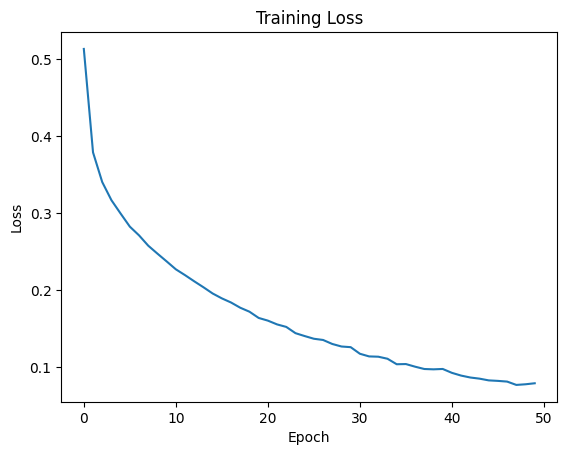

In [46]:
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

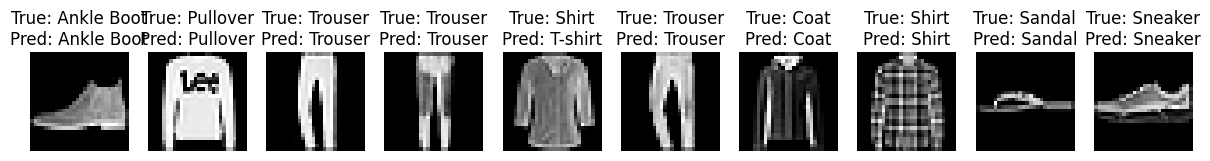

In [47]:
# Get some random test samples
images, labels = next(iter(test_loader))

# Move to CPU for visualization (ensure it's on CPU)
images, labels = images.cpu(), labels.cpu()

# Get predictions
with torch.no_grad():
    outputs = model(images.to(device))  # Move images to GPU for inference
    _, predicted = torch.max(outputs, 1)
    predicted = predicted.cpu()  # Move predictions to CPU

# Plot the first 5 images with their labels
fig, axes = plt.subplots(1, 10, figsize=(15, 5))
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", 
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

for i in range(10):
    axes[i].imshow(images[i].view(28, 28), cmap="gray")  # Ensure correct shape
    axes[i].set_title(f"True: {class_names[labels[i].item()]}\nPred: {class_names[predicted[i].item()]}")
    axes[i].axis("off")

plt.show()


In [48]:
correct = 0
total = 0

# Ensure model is in evaluation mode
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)  # Forward pass
        _, predicted = torch.max(outputs, 1)  # Get predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

# Compute accuracy
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 88.48%


<h1><center>Model (2)<center><h1>


In [49]:

class FashionMNIST_ANN(nn.Module):
    def __init__(self):
        super(FashionMNIST_ANN, self).__init__()
        self.fc1 = nn.Linear(784, 256)  # First hidden layer
        self.fc2 = nn.Linear(256, 128)   # Second hidden layer
        self.fc3 = nn.Linear(128, 64)    # third hidden layer
        self.fc4 = nn.Linear(64, 10)    # Output layer (10 classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))  # Activation function for first hidden layer
        x = F.relu(self.fc2(x))  # Activation function for second hidden layer
        x = F.relu(self.fc3(x))  # Activation function for third hidden layer
        x = self.fc4(x)          # No activation (logits for classification)
        return x


In [50]:
model = FashionMNIST_ANN()
print(model)

FashionMNIST_ANN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=10, bias=True)
)


In [51]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()  # Loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Optimizer with learning rate 0.001

In [52]:
from torch.utils.data import DataLoader
batch_size = 64  # You can adjust this
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [53]:
# Move model to GPU if available
model.to(device)
print(device)
num_epochs = 50
loss_history = []
for epoch in range(num_epochs):
    model.train()  
    running_loss = 0.0
    print(next(model.parameters()).device)  # Should print 'cuda'/'mps' if using GPU
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) 
        optimizer.zero_grad()  # Reset gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")
    loss_history.append(running_loss/len(train_loader))
print("Training complete!")


mps
mps:0
Epoch 1/50, Loss: 0.5157
mps:0
Epoch 2/50, Loss: 0.3794
mps:0
Epoch 3/50, Loss: 0.3403
mps:0
Epoch 4/50, Loss: 0.3126
mps:0
Epoch 5/50, Loss: 0.2925
mps:0
Epoch 6/50, Loss: 0.2743
mps:0
Epoch 7/50, Loss: 0.2636
mps:0
Epoch 8/50, Loss: 0.2501
mps:0
Epoch 9/50, Loss: 0.2398
mps:0
Epoch 10/50, Loss: 0.2277
mps:0
Epoch 11/50, Loss: 0.2183
mps:0
Epoch 12/50, Loss: 0.2138
mps:0
Epoch 13/50, Loss: 0.1999
mps:0
Epoch 14/50, Loss: 0.1949
mps:0
Epoch 15/50, Loss: 0.1848
mps:0
Epoch 16/50, Loss: 0.1807
mps:0
Epoch 17/50, Loss: 0.1741
mps:0
Epoch 18/50, Loss: 0.1616
mps:0
Epoch 19/50, Loss: 0.1585
mps:0
Epoch 20/50, Loss: 0.1531
mps:0
Epoch 21/50, Loss: 0.1464
mps:0
Epoch 22/50, Loss: 0.1410
mps:0
Epoch 23/50, Loss: 0.1345
mps:0
Epoch 24/50, Loss: 0.1321
mps:0
Epoch 25/50, Loss: 0.1237
mps:0
Epoch 26/50, Loss: 0.1213
mps:0
Epoch 27/50, Loss: 0.1180
mps:0
Epoch 28/50, Loss: 0.1140
mps:0
Epoch 29/50, Loss: 0.1126
mps:0
Epoch 30/50, Loss: 0.1065
mps:0
Epoch 31/50, Loss: 0.1061
mps:0
Epoch 3

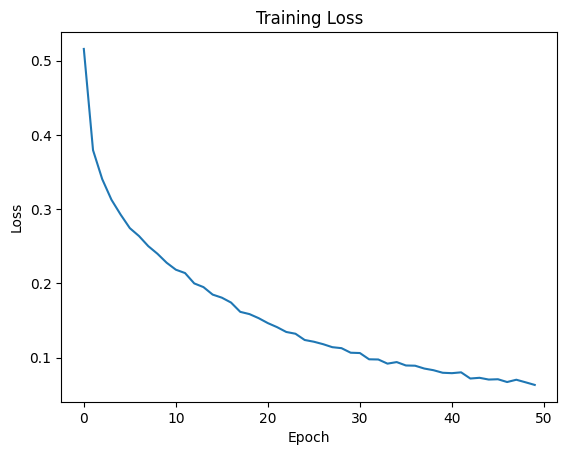

In [54]:
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

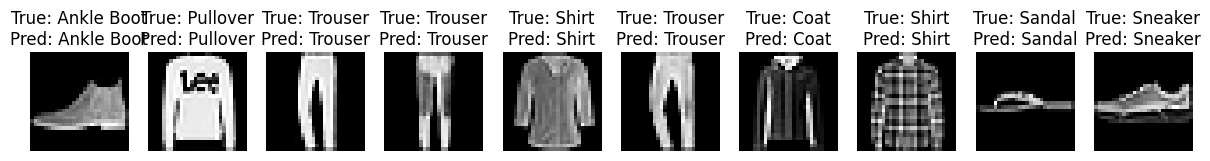

In [55]:
# Get some random test samples
images, labels = next(iter(test_loader))

# Move to CPU for visualization (ensure it's on CPU)
images, labels = images.cpu(), labels.cpu()

# Get predictions
with torch.no_grad():
    outputs = model(images.to(device))  # Move images to GPU for inference
    _, predicted = torch.max(outputs, 1)
    predicted = predicted.cpu()  # Move predictions to CPU

# Plot the first 5 images with their labels
fig, axes = plt.subplots(1, 10, figsize=(15, 5))
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", 
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

for i in range(10):
    axes[i].imshow(images[i].view(28, 28), cmap="gray")  # Ensure correct shape
    axes[i].set_title(f"True: {class_names[labels[i].item()]}\nPred: {class_names[predicted[i].item()]}")
    axes[i].axis("off")

plt.show()


In [56]:
correct = 0
total = 0

# Ensure model is in evaluation mode
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)  # Forward pass
        _, predicted = torch.max(outputs, 1)  # Get predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

# Compute accuracy
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 88.79%


<h1><center>Model (3)<center><h1>


In [57]:
class FashionMNIST_ANN(nn.Module):
    def __init__(self):
        super(FashionMNIST_ANN, self).__init__()
        self.fc1 = nn.Linear(784, 256)  # First hidden layer
        self.fc2 = nn.Linear(256, 256)   # Second hidden layer
        self.fc3 = nn.Linear(256, 128)    # third hidden layer
        self.fc4 = nn.Linear(128, 64)    # fourth hidden layer
        self.fc5 = nn.Linear(64, 10)    # Output layer (10 classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))  # Activation function for first hidden layer
        x = F.relu(self.fc2(x))  # Activation function for second hidden layer
        x = F.relu(self.fc3(x))  # Activation function for third hidden layer
        x = F.relu(self.fc4(x))  # Activation function for fourth hidden layer
        x = self.fc5(x)          # No activation (logits for classification)
        return x


In [58]:
model = FashionMNIST_ANN()
print(model)

FashionMNIST_ANN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=64, bias=True)
  (fc5): Linear(in_features=64, out_features=10, bias=True)
)


In [59]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()  # Loss function
optimizer = optim.Adam(model.parameters(), lr=0.002)  # Optimizer with learning rate 0.001

In [60]:
from torch.utils.data import DataLoader
batch_size = 64  # You can adjust this
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [61]:
# Move model to GPU if available
model.to(device)
print(device)
num_epochs = 70
loss_history = []
for epoch in range(num_epochs):
    model.train()  
    running_loss = 0.0
    print(next(model.parameters()).device)  # Should print 'cuda'/'mps' if using GPU
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) 
        optimizer.zero_grad()  # Reset gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")
    loss_history.append(running_loss/len(train_loader))
print("Training complete!")


mps
mps:0
Epoch 1/70, Loss: 0.5317
mps:0
Epoch 2/70, Loss: 0.3911
mps:0
Epoch 3/70, Loss: 0.3548
mps:0
Epoch 4/70, Loss: 0.3273
mps:0
Epoch 5/70, Loss: 0.3092
mps:0
Epoch 6/70, Loss: 0.2947
mps:0
Epoch 7/70, Loss: 0.2830
mps:0
Epoch 8/70, Loss: 0.2690
mps:0
Epoch 9/70, Loss: 0.2611
mps:0
Epoch 10/70, Loss: 0.2513
mps:0
Epoch 11/70, Loss: 0.2425
mps:0
Epoch 12/70, Loss: 0.2370
mps:0
Epoch 13/70, Loss: 0.2301
mps:0
Epoch 14/70, Loss: 0.2201
mps:0
Epoch 15/70, Loss: 0.2167
mps:0
Epoch 16/70, Loss: 0.2093
mps:0
Epoch 17/70, Loss: 0.2010
mps:0
Epoch 18/70, Loss: 0.1998
mps:0
Epoch 19/70, Loss: 0.1919
mps:0
Epoch 20/70, Loss: 0.1897
mps:0
Epoch 21/70, Loss: 0.1839
mps:0
Epoch 22/70, Loss: 0.1778
mps:0
Epoch 23/70, Loss: 0.1716
mps:0
Epoch 24/70, Loss: 0.1714
mps:0
Epoch 25/70, Loss: 0.1672
mps:0
Epoch 26/70, Loss: 0.1608
mps:0
Epoch 27/70, Loss: 0.1582
mps:0
Epoch 28/70, Loss: 0.1537
mps:0
Epoch 29/70, Loss: 0.1651
mps:0
Epoch 30/70, Loss: 0.1483
mps:0
Epoch 31/70, Loss: 0.1443
mps:0
Epoch 3

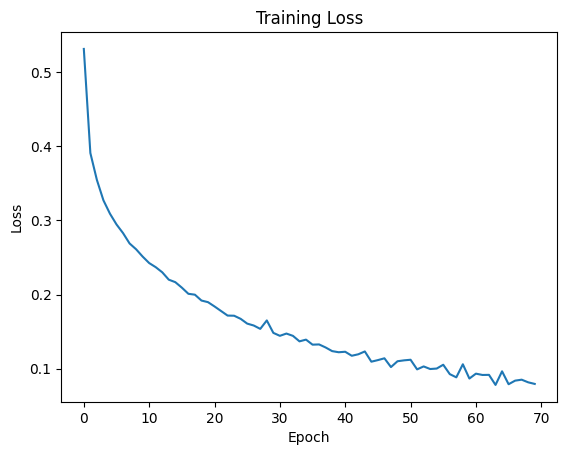

In [62]:
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

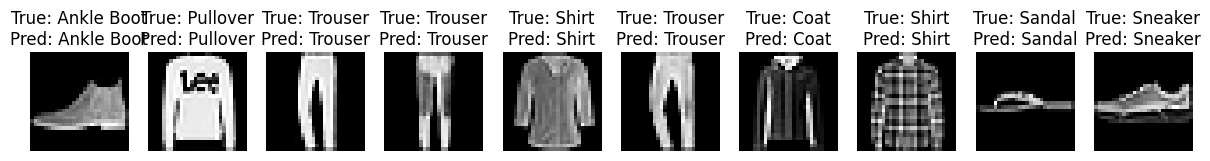

In [63]:
# Get some random test samples
images, labels = next(iter(test_loader))

# Move to CPU for visualization (ensure it's on CPU)
images, labels = images.cpu(), labels.cpu()

# Get predictions
with torch.no_grad():
    outputs = model(images.to(device))  # Move images to GPU for inference
    _, predicted = torch.max(outputs, 1)
    predicted = predicted.cpu()  # Move predictions to CPU

# Plot the first 5 images with their labels
fig, axes = plt.subplots(1, 10, figsize=(15, 5))
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", 
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

for i in range(10):
    axes[i].imshow(images[i].view(28, 28), cmap="gray")  # Ensure correct shape
    axes[i].set_title(f"True: {class_names[labels[i].item()]}\nPred: {class_names[predicted[i].item()]}")
    axes[i].axis("off")

plt.show()


In [64]:
correct = 0
total = 0

# Ensure model is in evaluation mode
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)  # Forward pass
        _, predicted = torch.max(outputs, 1)  # Get predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

# Compute accuracy
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 89.14%


<h2><center>Model Analysis<center><h2>


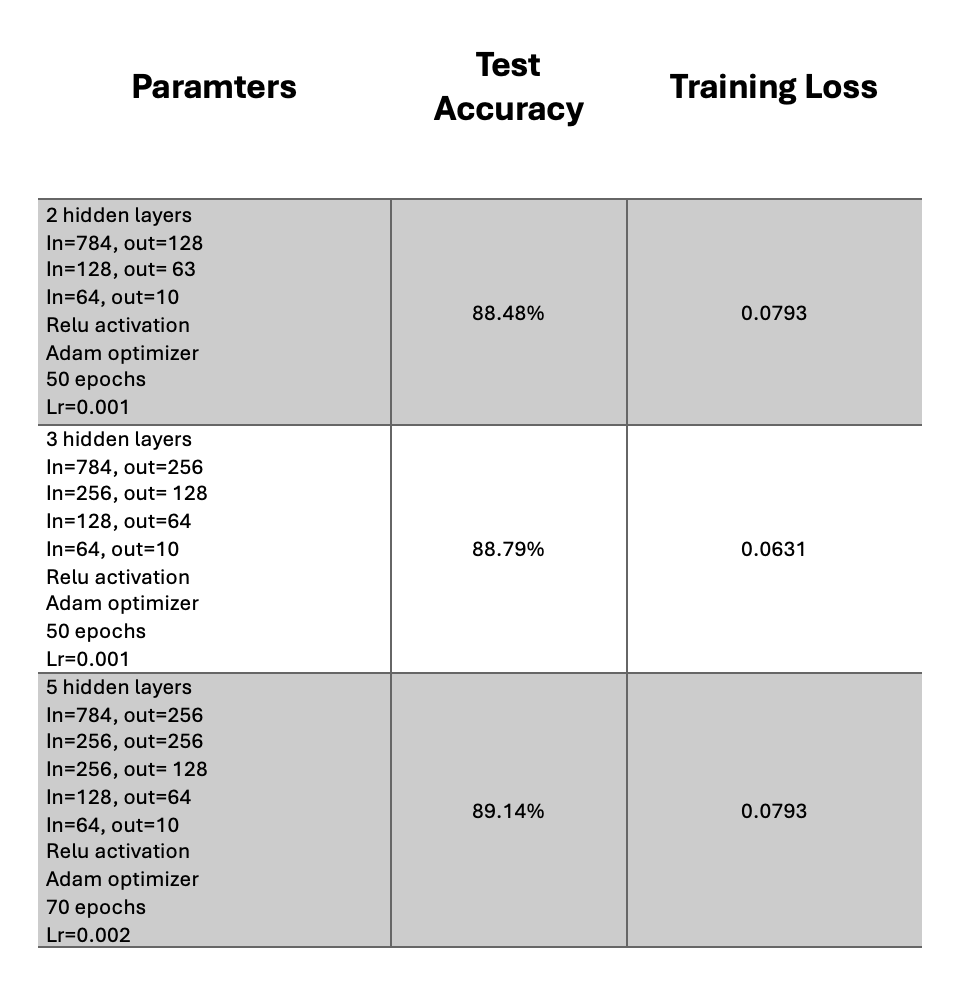


### **Analysis of Model Performance**

#### **Impact of Hidden Layers and Neurons**

- More hidden layers generally improve accuracy.
- **2 layers** → **88.48%**, **3 layers** → **88.79%**, **5 layers** → **89.14%**.
- The **5-layer model performed best**, likely due to capturing more complex patterns.

#### **Impact of Learning Rate and Epochs**

- **First two models:** LR = **0.001**, **50 epochs**.
- **5-layer model:** LR = **0.002**, **70 epochs** → highest accuracy.
- Increasing **LR and epochs** helped the model converge better.

#### **Impact on Training Loss**

- **3-layer model had the lowest training loss (0.0631)**, indicating better learning.
- **2-layer and 5-layer models had higher loss (0.0793)** → possible underfitting or overfitting.

#### **Summary**

- **Deeper networks can improve performance** but require careful tuning to avoid overfitting.
- **More epochs and a slightly higher learning rate** improved accuracy.
- **Beyond a certain depth, additional layers may increase training loss**, showing diminishing returns.
